# Methods, Results, and Discussion

Leona Myers (Colorado State University)  
Andie Hall (Colorado State University)

# Preliminary: Exploring the Data

In [ ]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

here() starts at C:/Users/myersl3/OneDrive - Rensselaer Polytechnic Institute/Documents/leonamyers/github/Final-Project-330

## CO2 data:

In [ ]:
Annua_CO2_Emissions <- read_csv(here("data", "annual-co2-emissions-per-country.csv"))

Rows: 54 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Entity
dbl (2): Year, Annual CO₂ emissions
lgl (1): Code

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

## Weather Data:

In [ ]:
AllWeatherData <- read_csv(here("data", "AllWeatherData.csv"))

Rows: 378 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): STATE
dbl (14): Year, Jan, Feb, Mar, Apr, May, Jun, Jul, Aug, Sep, Oct, Nov, Dec, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

## eBird Data:

In [ ]:
Wood_Thrush <- read_csv(here("data", "Wood_Thrush.csv"))

New names:
Rows: 301512 Columns: 27
── Column specification
──────────────────────────────────────────────────────── Delimiter: "," chr
(6): COUNTRY, COUNTRY CODE, STATE, COUNTY, OBSERVATION COUNT, OBSERVATI... dbl
(2): LATITUDE, LONGITUDE lgl (19): ...6, ...10, ...11, ...12, ...13, ...14,
...15, ...16, ...17, ...1...
ℹ Use `spec()` to retrieve the full column specification for this data. ℹ
Specify the column types or set `show_col_types = FALSE` to quiet this message.
• `` -> `...6`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`
• `` -> `...18`
• `` -> `...19`
• `` -> `...20`
• `` -> `...21`
• `` -> `...22`
• `` -> `...23`
• `` -> `...24`
• `` -> `...25`
• `` -> `...26`
• `` -> `...27`

# Data Manipulation

## Data Prep

In [ ]:
library(tidymodels)

── Attaching packages ────────────────────────────────────── tidymodels 1.2.0 ──

✔ broom        1.0.7     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.2.1
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.1.0
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filter()   masks stats::filter()
✖ recipes::fixed()  masks stringr::fixed()
✖ dplyr::lag()      masks stats::lag()
✖ yardstick::spec() masks readr::spec()
✖ recipes::step()   masks stats::step()
• Dig deeper into tidy modeling with R at https://www.tmwr.org


Attaching package: 'zoo'

The following objects are masked from 'package:base':

    as.Date, as.Date.numeric

In [ ]:
Wood_Thrush <- Wood_Thrush |>
  select(COUNTRY, `COUNTRY CODE`, STATE, `OBSERVATION COUNT`, `OBSERVATION DATE`, LATITUDE, LONGITUDE) |>
  mutate(`OBSERVATION DATE` = as.Date(`OBSERVATION DATE`, format = "%m/%d/%Y"),
         Year = year(`OBSERVATION DATE`))

Annual_Weather <- AllWeatherData |>
  select(Year, Annual, STATE)

Annua_CO2_Emissions <- Annua_CO2_Emissions |>
  select(Year, `Annual CO₂ emissions`)

Main_Data <- Wood_Thrush |>
  inner_join(Annual_Weather, by = c("Year", "STATE")) |>
  inner_join(Annua_CO2_Emissions, by = "Year") |>
  mutate(DayOfYear = yday(`OBSERVATION DATE`)) |>
  drop_na(Annual, `Annual CO₂ emissions`, DayOfYear)

## Creating Data sets

In [ ]:
Spring_Arrival <- Main_Data |>
  group_by(year(`OBSERVATION DATE`)) |>
  slice_min(`OBSERVATION DATE`, with_ties = FALSE)

Fall_Departure <- Main_Data |>
  group_by(year(`OBSERVATION DATE`)) |>
  slice_max(`OBSERVATION DATE`, with_ties = FALSE)

## Splitting and CV folds

In [ ]:
set.seed(123)
WT_split <- initial_split(Main_Data, prop = 0.8)
WT_train <- training(WT_split)
WT_test  <- testing(WT_split)
WT_cv <- vfold_cv(WT_train, v = 10)

## Recipe

In [ ]:
CO2_rec <- recipe(formula = DayOfYear ~ `Annual CO₂ emissions`, data = WT_train) |>
  step_log(all_predictors()) |>
  step_naomit(all_predictors(), all_outcomes())

Temp_rec <- recipe(formula = DayOfYear ~ Annual, data = WT_train) |>
  step_log(all_predictors()) |>
  step_naomit(all_predictors(), all_outcomes())

## Define Models

In [ ]:
lm_model <- linear_reg() |> set_engine("lm") |> set_mode("regression")
rf_model <- rand_forest() |> set_engine("ranger") |> set_mode("regression")
xg_model <- boost_tree() |> set_engine("xgboost") |> set_mode("regression")

## CO2 Workflows

In [ ]:
wf_lm_CO2 <- workflow() |>
  add_model(lm_model) |>
  add_recipe(CO2_rec)

wf_rf_CO2 <- workflow() |>
  add_model(rf_model) |>
  add_recipe(CO2_rec)

wf_xg_CO2 <- workflow() |>
  add_model(xg_model) |>
  add_recipe(CO2_rec)

## Temperature Workflows

In [ ]:
wf_lm_Temp <- workflow() |>
  add_model(lm_model) |>
  add_recipe(Temp_rec)

wf_rf_Temp <- workflow() |>
  add_model(rf_model) |>
  add_recipe(Temp_rec)

wf_xg_Temp <- workflow() |>
  add_model(xg_model) |>
  add_recipe(Temp_rec)

## CO2: Linear Model

In [ ]:
res_lm_CO2 <- fit_resamples(
  wf_lm_CO2,
  resamples = WT_cv,
  metrics = metric_set(rmse, rsq),
  control = control_resamples(save_pred = TRUE)
)

## CO2: Random Forest

In [ ]:
res_rf_CO2 <- fit_resamples(
  wf_rf_CO2,
  resamples = WT_cv,
  metrics = metric_set(rmse, rsq),
  control = control_resamples(save_pred = TRUE)
)

## CO2: Boosted Tree

In [ ]:
res_xg_CO2 <- fit_resamples(
  wf_xg_CO2,
  resamples = WT_cv,
  metrics = metric_set(rmse, rsq),
  control = control_resamples(save_pred = TRUE)
)

## Temp: Linear Model

In [ ]:
res_lm_Temp <- fit_resamples(
  wf_lm_Temp,
  resamples = WT_cv,
  metrics = metric_set(rmse, rsq),
  control = control_resamples(save_pred = TRUE)
)

## Temp: Random Forest

In [ ]:
res_rf_Temp <- fit_resamples(
  wf_rf_Temp,
  resamples = WT_cv,
  metrics = metric_set(rmse, rsq),
  control = control_resamples(save_pred = TRUE)
)

## Temp: Boosted Tree

In [ ]:
res_xg_Temp <- fit_resamples(
  wf_xg_Temp,
  resamples = WT_cv,
  metrics = metric_set(rmse, rsq),
  control = control_resamples(save_pred = TRUE)
)

## Model Performances

In [ ]:
all_results <- bind_rows(
  collect_metrics(res_lm_CO2) |> mutate(Model = "LM - CO2"),
  collect_metrics(res_rf_CO2) |> mutate(Model = "RF - CO2"),
  collect_metrics(res_xg_CO2) |> mutate(Model = "XG - CO2"),
  collect_metrics(res_lm_Temp) |> mutate(Model = "LM - Temp"),
  collect_metrics(res_rf_Temp) |> mutate(Model = "RF - Temp"),
  collect_metrics(res_xg_Temp) |> mutate(Model = "XG - Temp")
)

all_results |> 
  filter(.metric == "rmse") |> 
  arrange(mean)

# A tibble: 6 × 7
  .metric .estimator  mean     n std_err .config              Model    
  <chr>   <chr>      <dbl> <int>   <dbl> <chr>                <chr>    
1 rmse    standard    37.5    10  0.0590 Preprocessor1_Model1 RF - Temp
2 rmse    standard    37.5    10  0.0604 Preprocessor1_Model1 XG - Temp
3 rmse    standard    37.6    10  0.0598 Preprocessor1_Model1 RF - CO2 
4 rmse    standard    37.6    10  0.0608 Preprocessor1_Model1 XG - CO2 
5 rmse    standard    37.7    10  0.0608 Preprocessor1_Model1 LM - CO2 
6 rmse    standard    37.7    10  0.0606 Preprocessor1_Model1 LM - Temp

## Fit to Full Model (Spring and Fall)

In [ ]:
rf_temp_spring_fit <- fit(wf_rf_Temp, data = Spring_Arrival)

rf_temp_fall_fit <- fit(wf_rf_Temp, data = Fall_Departure)

## Plots and Predictions

In [ ]:
spring_preds <- predict(rf_temp_spring_fit, Spring_Arrival) |>
  bind_cols(Spring_Arrival)

fall_preds <- predict(rf_temp_fall_fit, Fall_Departure) |>
  bind_cols(Fall_Departure)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'

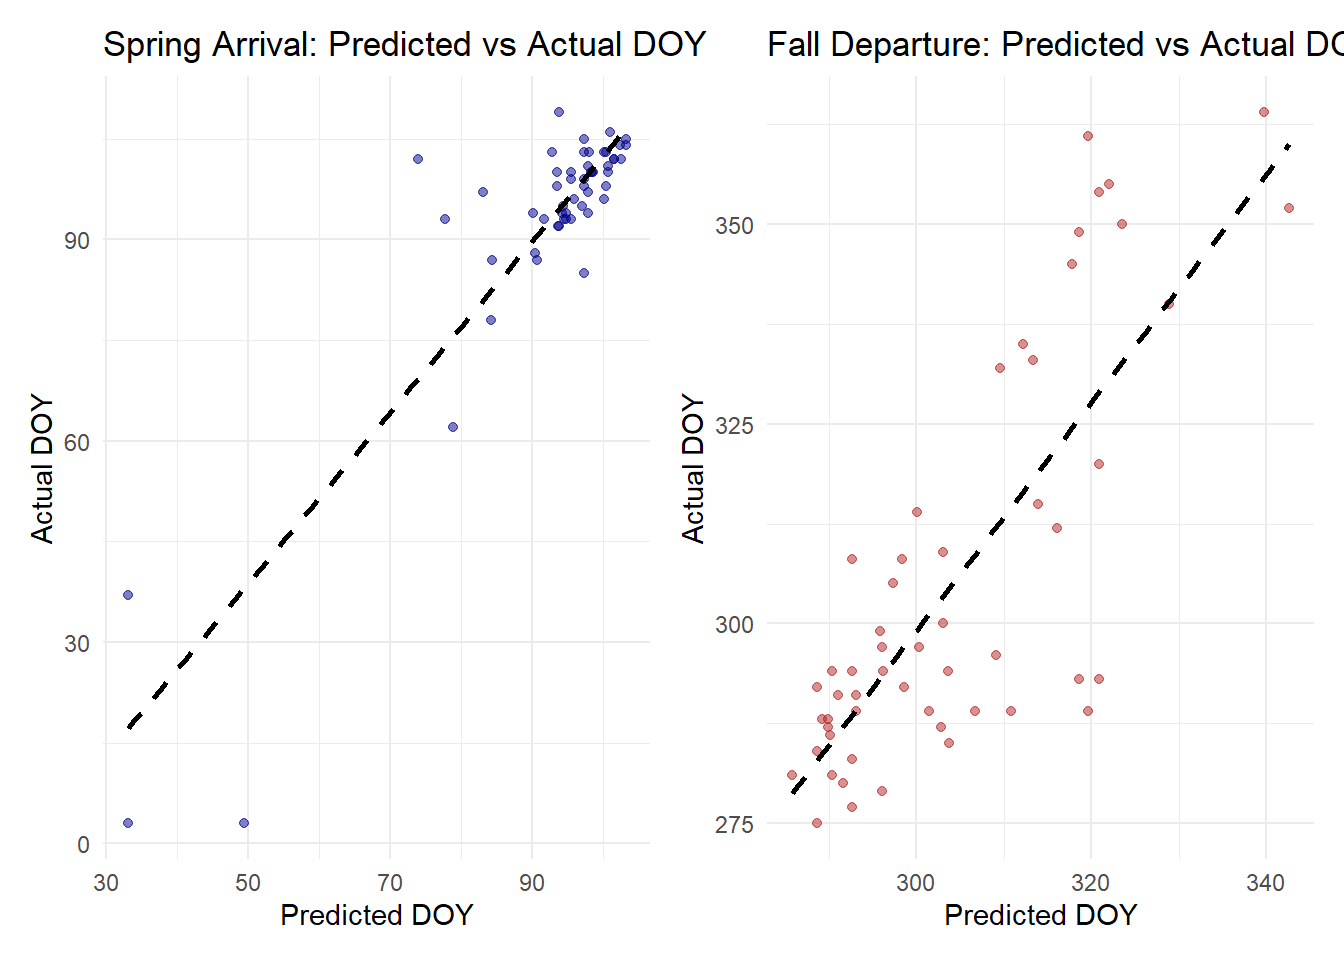

In [ ]:
library(patchwork) 

p1 <- ggplot(spring_preds, aes(x = .pred, y = DayOfYear)) +
  geom_point(alpha = 0.5, color = "darkblue") +
  geom_smooth(method = "lm", se = FALSE, color = "black", linetype = "dashed") +
  theme_minimal() +
  labs(title = "Spring Arrival: Predicted vs Actual DOY",
       x = "Predicted DOY", y = "Actual DOY")

p2 <- ggplot(fall_preds, aes(x = .pred, y = DayOfYear)) +
  geom_point(alpha = 0.5, color = "firebrick") +
  geom_smooth(method = "lm", se = FALSE, color = "black", linetype = "dashed") +
  theme_minimal() +
  labs(title = "Fall Departure: Predicted vs Actual DOY",
       x = "Predicted DOY", y = "Actual DOY")


p1 + p2

## Results

To examine the relationship between temperature and Wood Thrush migration phenology, we applied multiple modeling approaches (linear regression, random forest, and boosted trees) to predict the day of year of observations using annual temperature and CO₂ emissions as predictors. Among all models tested, the random forest model using annual temperature consistently performed best, showing the lowest root mean square error across 10-fold cross-validation.

We then used the RF-Temp model to separately predict spring arrival and fall departure dates. For spring arrival, the model demonstrated high accuracy, with predicted day of year closely aligning with actual arrival dates. This tight clustering around the 1:1 line indicates a strong relationship between annual temperature and early-season migratory behavior. While, predictions for fall departure showed greater variability and lower predictive performance suggesting that temperature is a less reliable cue for modeling autumn migration timing. These results suggest that spring migration is more tightly coupled to temperature trends. However, fall departure appears to be influenced by a more complex set of cues, potentially.

## Discussion